# Predictive Anayltics: Model Comparison

This notebook compares the SVM regression models against the trivial baselines from notebook 03_01.
Baseline metrics were persisted as parquet files, and SVM metrics were saved as CSV files after each training run.
Both are loaded here and combined into a single comparison table.

In [10]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import re

import datetime
from joblib import load, dump
import h3

from run_config import PATHS, MODELS_DIR

In [11]:
BASELINE_DIR = PATHS.train_test_dir / "baseline_predictions"
SVM_DIR = MODELS_DIR.parent / "svm"

## Load baseline metrics

In [12]:
baseline_metrics = (
    pl.read_parquet(BASELINE_DIR / "baseline_test_metrics.parquet")
    .rename({"baseline": "model"})
)

print(f"Loaded {baseline_metrics.height} baseline metric rows")
print("Datasets:", baseline_metrics["dataset"].unique().sort().to_list())

Loaded 576 baseline metric rows
Datasets: ['census_tracts_1h', 'census_tracts_24h', 'census_tracts_4h', 'community_areas_1h', 'community_areas_24h', 'community_areas_4h', 'community_areas_unfiltered_1h', 'community_areas_unfiltered_24h', 'community_areas_unfiltered_4h', 'hexagon_h3r7_1h', 'hexagon_h3r7_24h', 'hexagon_h3r7_4h']


## Load SVM metrics

The SVM notebooks saved a `result_*.csv` for each spatial/temporal configuration.
We load all of them and reshape into the same long format as the baseline metrics.

In [ ]:
def svm_tag_to_baseline_tag(svm_tag):
    # Map SVM filename tags like HEXAGON_7_4H to baseline tags like hexagon_h3r7_4h.
    tag = svm_tag.lower()
    # HEXAGON_7_4H -> hexagon_h3r7_4h
    match = re.match(r"hexagon_(\d+)_(\w+)", tag)
    if match:
        return f"hexagon_h3r{match.group(1)}_{match.group(2)}"
    # CENSUS_TRACTS_4H -> census_tracts_4h (already correct after lowering)
    # COMMUNITY_AREAS_4H -> community_areas_4h
    return tag

In [14]:
# Metric name mapping from SVM CSVs to baseline format
METRIC_RENAME = {
    "mae": "mae",
    "mse": "mse",
    "rmse": "rmse",
    "r2 score": "r2",
    "r2_score": "r2",
}

rows = []
for f in sorted(SVM_DIR.glob("result_*.csv")):
    # filename: result_CENSUS_TRACTS_4H.csv
    svm_tag = f.stem.replace("result_", "")
    dataset_tag = svm_tag_to_baseline_tag(svm_tag)

    result = pd.read_csv(f)
    for col in result.columns:
        metric_name = METRIC_RENAME.get(col.lower().strip(), col.lower().strip())
        rows.append({
            "dataset": dataset_tag,
            "model": "svm",
            "metric": metric_name,
            "value": float(result[col].iloc[0]),
        })

svm_metrics = pl.DataFrame(rows)
print(f"Loaded SVM metrics for {svm_metrics['dataset'].n_unique()} configurations")
print("Datasets:", svm_metrics["dataset"].unique().sort().to_list())

Loaded SVM metrics for 12 configurations
Datasets: ['census_tracts_1h', 'census_tracts_24h', 'census_tracts_4h', 'community_areas_1h', 'community_areas_24h', 'community_areas_4h', 'hexagon_h3r7_1h', 'hexagon_h3r7_24h', 'hexagon_h3r7_4h', 'hexagon_h3r8_1h', 'hexagon_h3r8_24h', 'hexagon_h3r8_4h']


## Combine all metrics

In [15]:
all_metrics = pl.concat([baseline_metrics, svm_metrics])

# Only keep datasets where we have both baselines and SVM results
baseline_datasets = set(baseline_metrics["dataset"].unique().to_list())
svm_datasets = set(svm_metrics["dataset"].unique().to_list())
common_datasets = sorted(baseline_datasets & svm_datasets)

print(f"Datasets with both baseline and SVM: {common_datasets}")

svm_only = svm_datasets - baseline_datasets
if svm_only:
    print(f"Warning: SVM-only (no matching baseline): {sorted(svm_only)}")

Datasets with both baseline and SVM: ['census_tracts_1h', 'census_tracts_24h', 'census_tracts_4h', 'community_areas_1h', 'community_areas_24h', 'community_areas_4h', 'hexagon_h3r7_1h', 'hexagon_h3r7_24h', 'hexagon_h3r7_4h']


## Comparison tables

One table per dataset, pivoted so models are columns.

In [16]:
DISPLAY_METRICS = ["mae", "rmse", "r2"]

for dataset in common_datasets:
    print(f"\n{'='*60}")
    print(f"  {dataset}")
    print(f"{'='*60}")

    table = (
        all_metrics
        .filter(
            pl.col("dataset") == dataset,
            pl.col("metric").is_in(DISPLAY_METRICS),
        )
        .pivot(on="model", index="metric", values="value")
        .sort("metric")
    )

    numeric_cols = [c for c in table.columns if c != "metric"]
    table = table.with_columns([pl.col(c).round(3) for c in numeric_cols])
    print(table)


  census_tracts_1h
shape: (3, 5)
┌────────┬────────┬───────────────┬───────────────────────────┬───────┐
│ metric ┆ zero   ┆ global_median ┆ spatial_time_weekday_mean ┆ svm   │
│ ---    ┆ ---    ┆ ---           ┆ ---                       ┆ ---   │
│ str    ┆ f64    ┆ f64           ┆ f64                       ┆ f64   │
╞════════╪════════╪═══════════════╪═══════════════════════════╪═══════╡
│ mae    ┆ 0.36   ┆ 0.36          ┆ 0.136                     ┆ 0.359 │
│ r2     ┆ -0.006 ┆ -0.006        ┆ 0.878                     ┆ 0.548 │
│ rmse   ┆ 4.617  ┆ 4.617         ┆ 1.609                     ┆ 3.094 │
└────────┴────────┴───────────────┴───────────────────────────┴───────┘

  census_tracts_24h
shape: (3, 5)
┌────────┬────────┬───────────────┬───────────────────────────┬────────┐
│ metric ┆ zero   ┆ global_median ┆ spatial_time_weekday_mean ┆ svm    │
│ ---    ┆ ---    ┆ ---           ┆ ---                       ┆ ---    │
│ str    ┆ f64    ┆ f64           ┆ f64                       ┆ 

## Visualization: SVM vs best baseline

Compare the SVM model against the strongest baseline (spatial_time_weekday_mean) across all datasets.

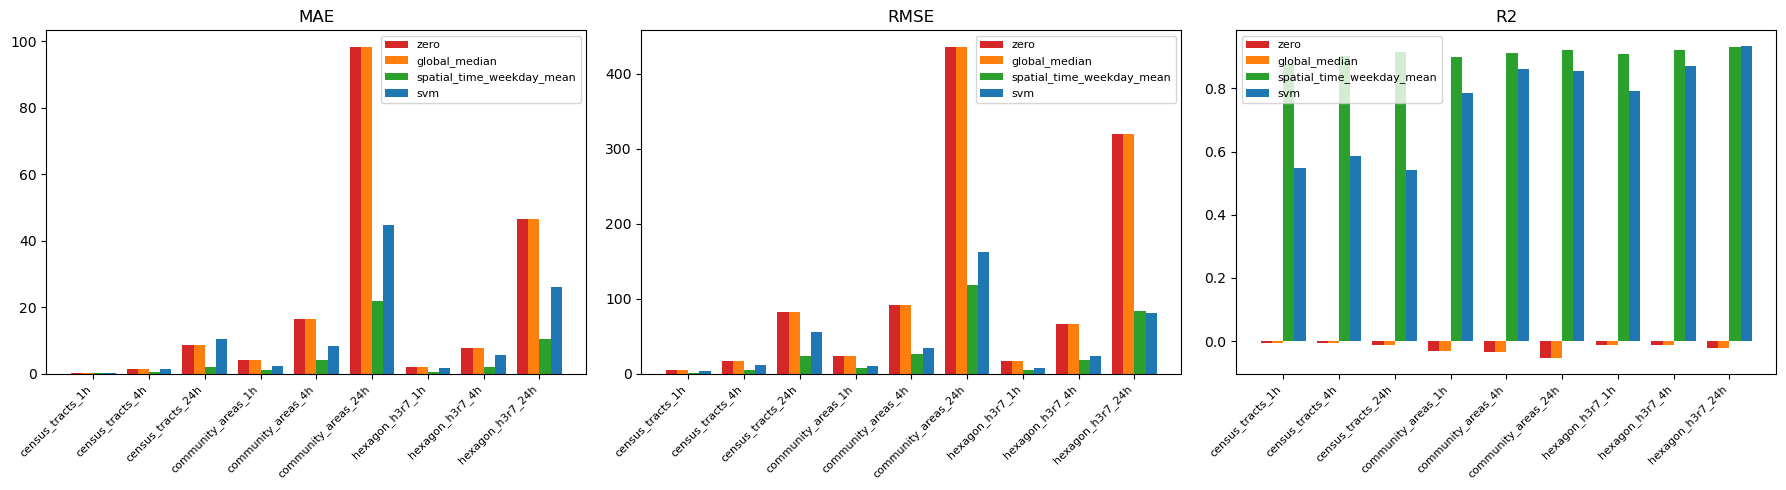

In [21]:
comparison_df = (
    all_metrics
    .filter(
        pl.col("dataset").is_in(common_datasets),
        pl.col("model").is_in(["zero", "global_median", "spatial_time_weekday_mean", "svm"]),
        pl.col("metric").is_in(DISPLAY_METRICS),
    )
)

MODELS = ["zero", "global_median", "spatial_time_weekday_mean", "svm"]
COLORS = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

TIME_ORDER = {"1h": 0, "4h": 1, "24h": 2}

def sort_key(dataset):
    match = re.match(r"^(.+)_(\d+h)$", dataset)
    if match:
        spatial, time = match.groups()
        return (spatial, TIME_ORDER.get(time, 99))
    return (dataset, 99)

fig, axes = plt.subplots(1, len(DISPLAY_METRICS), figsize=(6 * len(DISPLAY_METRICS), 5))

for i, metric in enumerate(DISPLAY_METRICS):
    metric_data = comparison_df.filter(pl.col("metric") == metric)
    datasets = sorted(metric_data["dataset"].unique().to_list(), key=sort_key)
    x = np.arange(len(datasets))
    width = 0.2

    for j, model in enumerate(MODELS):
        vals = []
        for d in datasets:
            row = metric_data.filter((pl.col("dataset") == d) & (pl.col("model") == model))
            vals.append(row["value"][0] if row.height > 0 else 0)

        offset = (j - len(MODELS) / 2 + 0.5) * width
        axes[i].bar(x + offset, vals, width, label=model, color=COLORS[j])

    axes[i].set_title(metric.upper())
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(datasets, rotation=45, ha="right", fontsize=8)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Effect of spatial and temporal resolution

How does SVM performance change across different spatial units and time buckets?

In [18]:
svm_only_df = all_metrics.filter(
    pl.col("model") == "svm",
    pl.col("dataset").is_in(common_datasets),
)

# Split dataset tag into spatial and temporal parts
svm_resolution = svm_only_df.with_columns(
    pl.col("dataset").str.extract(r"^(.+)_(\d+h)$", 1).alias("spatial_unit"),
    pl.col("dataset").str.extract(r"^(.+)_(\d+h)$", 2).alias("time_unit"),
)

for metric in DISPLAY_METRICS:
    pivot = (
        svm_resolution
        .filter(pl.col("metric") == metric)
        .pivot(on="time_unit", index="spatial_unit", values="value")
        .sort("spatial_unit")
    )
    numeric_cols = [c for c in pivot.columns if c != "spatial_unit"]
    pivot = pivot.with_columns([pl.col(c).round(3) for c in numeric_cols])

    print(f"\nSVM {metric.upper()} by spatial unit and time resolution:")
    print(pivot)


SVM MAE by spatial unit and time resolution:
shape: (3, 4)
┌─────────────────┬───────┬────────┬───────┐
│ spatial_unit    ┆ 1h    ┆ 24h    ┆ 4h    │
│ ---             ┆ ---   ┆ ---    ┆ ---   │
│ str             ┆ f64   ┆ f64    ┆ f64   │
╞═════════════════╪═══════╪════════╪═══════╡
│ census_tracts   ┆ 0.359 ┆ 10.596 ┆ 1.349 │
│ community_areas ┆ 2.379 ┆ 44.689 ┆ 8.464 │
│ hexagon_h3r7    ┆ 1.635 ┆ 26.1   ┆ 5.527 │
└─────────────────┴───────┴────────┴───────┘

SVM RMSE by spatial unit and time resolution:
shape: (3, 4)
┌─────────────────┬────────┬─────────┬────────┐
│ spatial_unit    ┆ 1h     ┆ 24h     ┆ 4h     │
│ ---             ┆ ---    ┆ ---     ┆ ---    │
│ str             ┆ f64    ┆ f64     ┆ f64    │
╞═════════════════╪════════╪═════════╪════════╡
│ census_tracts   ┆ 3.094  ┆ 55.657  ┆ 11.272 │
│ community_areas ┆ 10.956 ┆ 161.657 ┆ 33.768 │
│ hexagon_h3r7    ┆ 7.819  ┆ 80.918  ┆ 23.812 │
└─────────────────┴────────┴─────────┴────────┘

SVM R2 by spatial unit and time resolutio

## Resolution heatmap

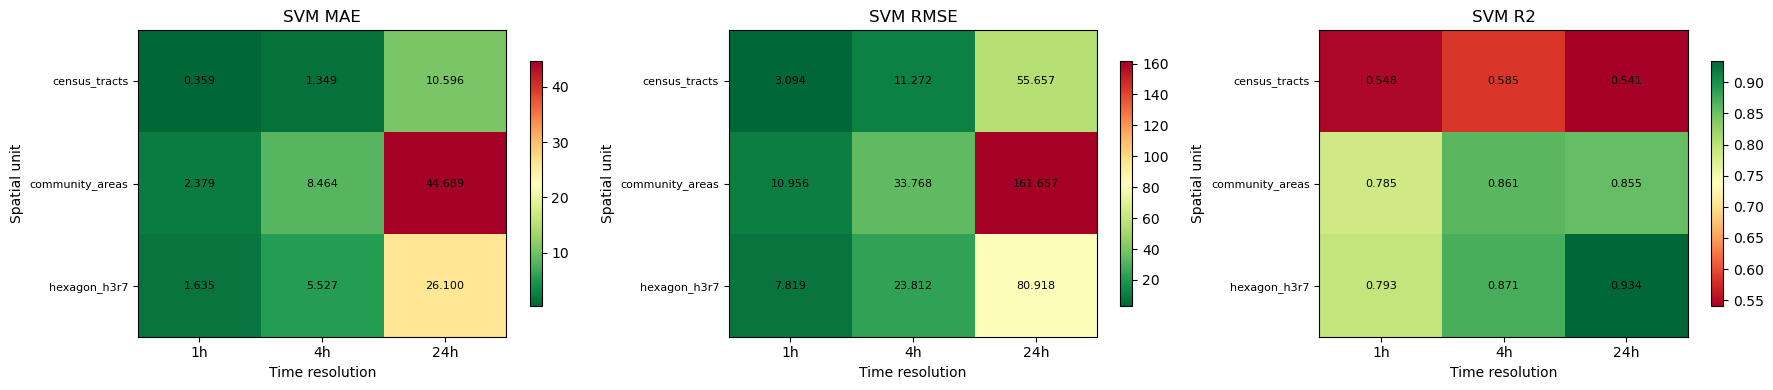

In [22]:
fig, axes = plt.subplots(1, len(DISPLAY_METRICS), figsize=(6 * len(DISPLAY_METRICS), 4))

for i, metric in enumerate(DISPLAY_METRICS):
    pivot = (
        svm_resolution
        .filter(pl.col("metric") == metric)
        .pivot(on="time_unit", index="spatial_unit", values="value")
        .sort("spatial_unit")
    )

    spatial_units = pivot["spatial_unit"].to_list()
    time_cols = sorted([c for c in pivot.columns if c != "spatial_unit"], key=lambda t: TIME_ORDER.get(t, 99))
    matrix = pivot.select(time_cols).to_numpy()

    im = axes[i].imshow(matrix, cmap="RdYlGn" if metric == "r2" else "RdYlGn_r", aspect="auto")
    axes[i].set_xticks(range(len(time_cols)))
    axes[i].set_xticklabels(time_cols)
    axes[i].set_yticks(range(len(spatial_units)))
    axes[i].set_yticklabels(spatial_units, fontsize=8)
    axes[i].set_title(f"SVM {metric.upper()}")
    axes[i].set_xlabel("Time resolution")
    axes[i].set_ylabel("Spatial unit")

    # Annotate cells with values
    for row in range(len(spatial_units)):
        for col in range(len(time_cols)):
            val = matrix[row, col]
            if not np.isnan(val):
                axes[i].text(col, row, f"{val:.3f}", ha="center", va="center", fontsize=8)

    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.show()